**1. BUSINESS UNDERSTANDING**

The telecommunications industry in Syria is highly dynamic, with an oligopolistic market dominated by major competitors MTN Syria and NewComer Wafa Telecom. SyriaTel has been facing a challenge: customers don't stay long and end up switching to competitors.

**BUSINESS OBJECTIVES**
The primary objective is to ascertain if there are any predictable trends in the data that can help the company make informed decisions. The specific objectives are as follows
1. To identify any patterns indicated by the data as far as customers leaving the company is concerned.
2. To ascertain if the patterns indicate particular reasons why customers don't stay for long with SyriaTel.
3. To provide recommendations on what can be done differently to ensure that customers stay for longer.

**BUSINESS QUESTIONS**
1. Are there any trends in the data presented?
2. Are the trends predictive of any possible scenarios?

The project is expected to be a success if there's certainty that there are patterns in the data presented or not; and if patterns exist, that recommendations are provided to management on a way forward to ensure that decisions are made so that less money is lost through customer churn.


**2. DATA UNDERSTANDING**

The data was obtained from Kaggle and represents the Churn in SyriaTel'c customers. This is the rate at which customers leave the company and end up procuring the services of competitors.
The dataset contains data about customers ranging from the location of a customer, account numbders, minutes of calls across different service packages i.e local calls, international calls etc., telephone charges, customer churn etc.

Preliminary analysis on the data for better understanding and determining the best metrics that will achieve the objectives of the project

In [1]:
#Importation of necesarry libraries for the project.
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler

In [2]:
#Loading the dataset
df = pd.read_csv('bigml_59c28831336c6604c800002a.csv')
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
#Checking for the descriptive statistics for the data.
df.info()

#Observations
#The dataset contains 21 columns and 3,333 rows of data, which encompass various aspects of SyriaTel's clients. From phone numbers, to details about the
#calls and packages they subscribe to and whether they have left the company or not i.e churn.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [4]:
#Checking through the 'churn' column to see the elements contained in there as the data is in boolean form.
print(df['churn'].unique())
print(df['churn'].value_counts())
#Observation
#The data in the column is in True or False, indicating whether a client has left the company or not.
#There are 483 customers that have 'True' return in the dataset indicating that they left the company. This represents around 14% of the total data which
#is not alarming, however, the company would still be interested in bringing this figure down.

[False  True]
churn
False    2850
True      483
Name: count, dtype: int64


**3. DATA PREPARATION AND CLEANING**

In [5]:
#Identifying blanks rows in the dataset
df.isna().sum()

#Observation
#The data has no missing information signifying that it should be very clean and fit for the project.

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

In [6]:
#Identifying if there are any duplicates in the phone number column, as that should be the unique identifier
df['phone number'].duplicated().sum()
#The phone number column has no duplicates, meaning that each phone number in the dataset is unique.

0

An extra step could have been renaming the columns. However, there is already consistency in how the columns are named hence renaming columns by adding maybe underscores to separate each word doesn't add any value to the dataset.

In [7]:
#Checking the states that are there in the dataset, this is to see if there is any relationship between churn and the state later
#in the project
df['state'].unique()

array(['KS', 'OH', 'NJ', 'OK', 'AL', 'MA', 'MO', 'LA', 'WV', 'IN', 'RI',
       'IA', 'MT', 'NY', 'ID', 'VT', 'VA', 'TX', 'FL', 'CO', 'AZ', 'SC',
       'NE', 'WY', 'HI', 'IL', 'NH', 'GA', 'AK', 'MD', 'AR', 'WI', 'OR',
       'MI', 'DE', 'UT', 'CA', 'MN', 'SD', 'NC', 'WA', 'NM', 'NV', 'DC',
       'KY', 'ME', 'MS', 'TN', 'PA', 'CT', 'ND'], dtype=object)

In [8]:
#Running the dataset's columns to identify the columns that are relevant in the project; and whether there is possibility of creating secondary datasets
df.columns

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

At this point, the data has no duplicates, no blank rows, the columns are also named consistently, the data is also in formats that can be used for further analysis as they are. More columns may need to be added to the dataset to provide further insights and provide different perspectives on why or what customers churn more than others.

Some columns are not relevant to the objective of the project and these will be dropped, and the reasons for doing so are listed below:

1. 'State' - The state doesn't really have any sort of relationship to whether a customer leaves the company. Unless non-existent factors like connectivity in some states are brought in. With the prevailing information, there is no relevance as to whether a customer leaves.
2. 'area code' - Again, this has no relevanace as to whether a client leaves. This is just for the customer's descriptive purposes.

In [9]:
#Dropping state and area code columns as they are irrelevant to the project.
df.drop(columns = ['state','area code'])
#Observation
#An updated dataset without the aforementioned columns

,account length,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,128,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,192,414-4276,no,yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,68,370-3271,no,no,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,28,328-8230,no,no,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,184,364-6381,yes,no,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


There are some colums that may not be a cause for customer churn, but actually be a reason why a customer is retained. These columns include 'international plan' and 'voice mail plan'. These are service packages that enhance loyalty in a customer and end up in them staying with the company for longer.

The client phone number stays as it is the unique identifier of each client. Even when we have a client who has more than 1 phone number, each phone number they have contributes to whether they churn in an independent manner.

In [10]:
#Running the dataset for visibility
df.head(1)

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.7,1,False


In [11]:
#Adding a column for total number of minutes made by a customer. This is by adding day minutes, evening minutes, nigh minutes and international minutes
#The intention is to finally compute an average charge per minute to see if there's consistency in how customers are charged.
df['total minutes'] = df['total day minutes'] + df['total eve minutes']+ df['total night minutes'] + df['total intl minutes']

In [12]:
#Running the column to see if changes have been reflected
df['total minutes'].head()

0    717.2
1    625.2
2    539.4
3    564.8
4    512.0
Name: total minutes, dtype: float64

In [13]:
#Adding a column for total charge by adding all charges in the original dataset. The aim is as mentioned above that we are trying to see if there
#a patern in how customers are charged.
df['total charge'] = df['total day charge'] + df['total eve charge'] + df['total night charge'] + df['total intl charge']
df['total charge'].head()

0    75.56
1    59.24
2    62.29
3    66.80
4    52.09
Name: total charge, dtype: float64

In [14]:
#Adding a column on average charge per minute to see if there is consistency on how customers are charged
df['average charge'] = df['total charge']/df['total minutes']
df['average charge'].head()

0    0.105354
1    0.094754
2    0.115480
3    0.118272
4    0.101738
Name: average charge, dtype: float64

In [15]:
#Finding the range of the average charges
range_charge = df['average charge'].max() - df['average charge'].min()
range_charge

#Observation
#There is already a range of 0.063 per minute which already signifies that there is some inconsistencies on how customers are charged for services.
#This may be a contribution  to customer church but that will be ascertained as we go.

0.06284112317792222

In [16]:
#This is to cement the observation above about having inconsistencies in the way customers are charged for services.
df['average charge'].describe()

count    3333.000000
mean        0.100354
std         0.008440
min         0.066950
25%         0.094893
50%         0.100385
75%         0.106056
max         0.129791
Name: average charge, dtype: float64

In [17]:
#Running the dataset for visibility of the columns.
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn,total minutes,total charge,average charge
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,91,11.01,10.0,3,2.70,1,False,717.2,75.56,0.105354
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,11.45,13.7,3,3.70,1,False,625.2,59.24,0.094754
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,104,7.32,12.2,5,3.29,0,False,539.4,62.29,0.115480
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,89,8.86,6.6,7,1.78,2,False,564.8,66.80,0.118272
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,121,8.41,10.1,3,2.73,3,False,512.0,52.09,0.101738


**VISUALIZATION**

In [18]:
df['churn'].head()

0    False
1    False
2    False
3    False
4    False
Name: churn, dtype: bool

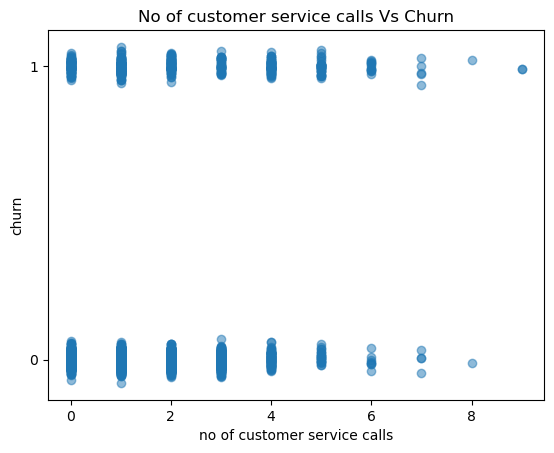

In [19]:
#Plotting a scatter plot for the number of customer service calls and churn count.
# X = independent variable which is the number of customer service calls

X = df['customer service calls']

#y = dependent variable which is whether there is churn
df['churn']=df['churn'].astype(int)
y = df['churn']

y_jittered = y + np.random.normal(0, 0.02, size=len(y))
plt.scatter(X, y_jittered, alpha=0.5)
plt.yticks([0, 1])
plt.xlabel("no of customer service calls")
plt.ylabel("churn")
plt.title("No of customer service calls Vs Churn")
plt.show()

The plot above shows a relationship between customer service calls and churn rate. There are clients that end up churning even where there are zero calls to customer service probably due to different reasons which may or may not be ascertained in this project. However, as the number of calls to customer service increase, the churn rate fluctuates up and down untl a point where it reduces. This shows that as much as clients leave the company due to high customer service calls, most of them don't stay to a point where the recurring calls have exceed 5 leading to the churn rate reducing as the calls to customer service increase.

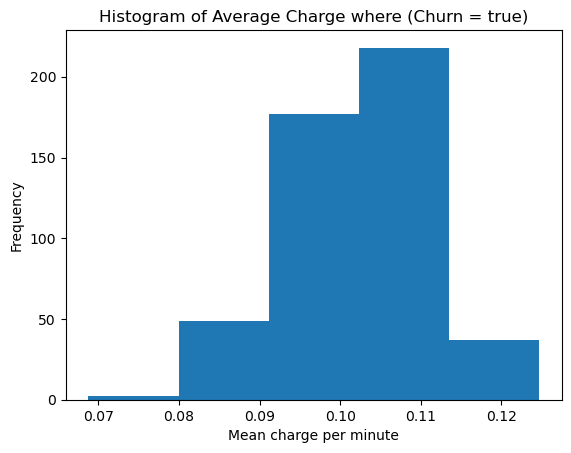

In [32]:
#Plotting a histogram for the average charge per minute against the frequence of Trues in the 'churn' column

#Filtering the rows where churn is 1 i.e True
churn_true = df[df['churn'] == 1]

plt.hist(churn_true['average charge'], bins= 5)
plt.xlabel('Mean charge per minute')
plt.ylabel('Frequency')
plt.title('Histogram of Average Charge where (Churn = true)')
plt.show()

The histogram above shows 2 things:
1. That as the average charge per minute increases, there is higher customer churn.
2. That there is inconsistency in how cusstomers are charged in the company and that may be the reason for the alarming churn rate in the company.

In [35]:
#Running the initial dataset for visibility
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn,total minutes,total charge,average charge
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,91,11.01,10.0,3,2.70,1,0,717.2,75.56,0.105354
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,11.45,13.7,3,3.70,1,0,625.2,59.24,0.094754
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,104,7.32,12.2,5,3.29,0,0,539.4,62.29,0.115480
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,89,8.86,6.6,7,1.78,2,0,564.8,66.80,0.118272
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,121,8.41,10.1,3,2.73,3,0,512.0,52.09,0.101738


In [36]:
df['churn'].unique()

array([0, 1])

DATA MODELLING

IKWDUFUDYGIGFUIRHGU

MODEL EVALUATION

JSDFGKDTFUEFIQEIFGEUI